# Residual Neural Network for Bioactivity Prediction

This notebook implements a **ResNet-style** neural network with skip connections and L2 regularization.
Motivation: the baseline and dropout DNNs plateau at epoch Aprox 63 with R² = 0.70, indicating the architecture
is the bottleneck. Skip connections allow gradients to flow through shortcut paths and enable the network
to learn delta corrections on top of earlier representations, well-suited for sparse binary fingerprint inputs.

### Imports

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Reproducibility, same seed as other notebooks
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['LOKY_MAX_CPU_COUNT'] = '10'

### Load & Prepare Data

Identical split and scaling to `5_Neural_Network.ipynb` so metrics are directly comparable.

In [2]:
df = pd.read_csv('train_data.csv')
df_test = pd.read_csv('test_data.csv')

X = df.drop('pIC50', axis=1)
Y = df['pIC50']
X_test = df_test.drop('pIC50', axis=1)
Y_test = df_test['pIC50']

print(f"Train features : {X.shape}")
print(f"Test features  : {X_test.shape}")

Train features : (13335, 1102)
Test features  : (3651, 1102)


#### 80/20 train-validation split 

In [ ]:
X_train_us, X_val_us, Y_train_us, Y_val_us = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Scale features, fit on train only 
scaler_x = StandardScaler()
X_train = scaler_x.fit_transform(X_train_us)
X_val   = scaler_x.transform(X_val_us)
X_test_scaled = scaler_x.transform(X_test)

# Scale target
scaler_y = StandardScaler()
Y_train = scaler_y.fit_transform(Y_train_us.values.reshape(-1, 1)).flatten()
Y_val   = scaler_y.transform(Y_val_us.values.reshape(-1, 1)).flatten()

print(f"X_train: {X_train.shape},  Y_train: {Y_train.shape}")
print(f"X_val  : {X_val.shape},    Y_val  : {Y_val.shape}")
print(f"X_test : {X_test_scaled.shape}")

X_train: (10668, 1102),  Y_train: (10668,)
X_val  : (2667, 1102),    Y_val  : (2667,)
X_test : (3651, 1102)


### Residual Network Architecture

In [ ]:
def residual_block(x, units, dropout_rate, l2_reg=1e-4):
    # Shortcut projection(aligns dimensions for the Add layer)
    shortcut = layers.Dense(units, kernel_regularizer=l2(l2_reg), use_bias=False)(x)

    # Main path
    x = layers.Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)

    # Skip connection
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


def build_resnet(input_dim, l2_reg=1e-4):
    inputs = keras.Input(shape=(input_dim,), name='fingerprint_input')

    # Initial projection layer
    x = layers.Dense(512, activation='relu', kernel_regularizer=l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Residual Block 1: 512 → 256
    x = residual_block(x, units=256, dropout_rate=0.3, l2_reg=l2_reg)

    # Residual Block 2: 256 → 128
    x = residual_block(x, units=128, dropout_rate=0.2, l2_reg=l2_reg)

    # Final dense layers
    x = layers.Dense(64, activation='relu', kernel_regularizer=l2(l2_reg))(x)

    # Output 
    outputs = layers.Dense(1, activation='linear', name='pIC50_output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='ResNet_QSAR')
    return model


model_res = build_resnet(input_dim=X_train.shape[1])
model_res.summary()

Model: "ResNet_QSAR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fingerprint_input   │ (None, 1102)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    564,736 │ fingerprint_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     65,792 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,072 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ batch_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256)       │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     16,512 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     32,768 │ activation_1[0][

 Total params: 988,545 (3.77 MB)

 Trainable params: 985,985 (3.76 MB)

 Non-trainable params: 2,560 (10.00 KB)

### Training the data

- **Adam** with lr=0.001: adaptive per-parameter updates, best for sparse fingerprint data
- **EarlyStopping** patience=50: wider window to let `ReduceLROnPlateau` cycle through LR reductions
- **ReduceLROnPlateau**: halves LR when val_loss stalls, enabling finer convergence at lower LR

In [5]:
model_res.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['RootMeanSquaredError', 'r2_score']
)

early_stop_res = EarlyStopping(
    monitor='val_loss', patience=50,
    restore_best_weights=True, verbose=1
)
lr_scheduler_res = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10,
    min_lr=1e-6, verbose=1
)

history_res = model_res.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=1000,
    batch_size=32,
    callbacks=[early_stop_res, lr_scheduler_res],
    verbose=0
)

results_res = model_res.evaluate(X_val, Y_val, verbose=0)
print(f"ResNet — Val Loss: {results_res[0]:.4f}, RMSE: {results_res[1]:.4f}, R²: {results_res[2]:.4f}")


Epoch 49: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 72: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 101: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 124: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 147: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 191: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 203: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 230: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.

Epoch 240: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.

Epoch 250: ReduceLROnPlateau reducing learning rate to 1e-06.
Epoch 270: early stopping
Restoring model weights from the end of the best epoch: 220.
ResNet — Val Loss: 0.3154, RMSE: 0.5471, R²: 0.7079


### Training Curves

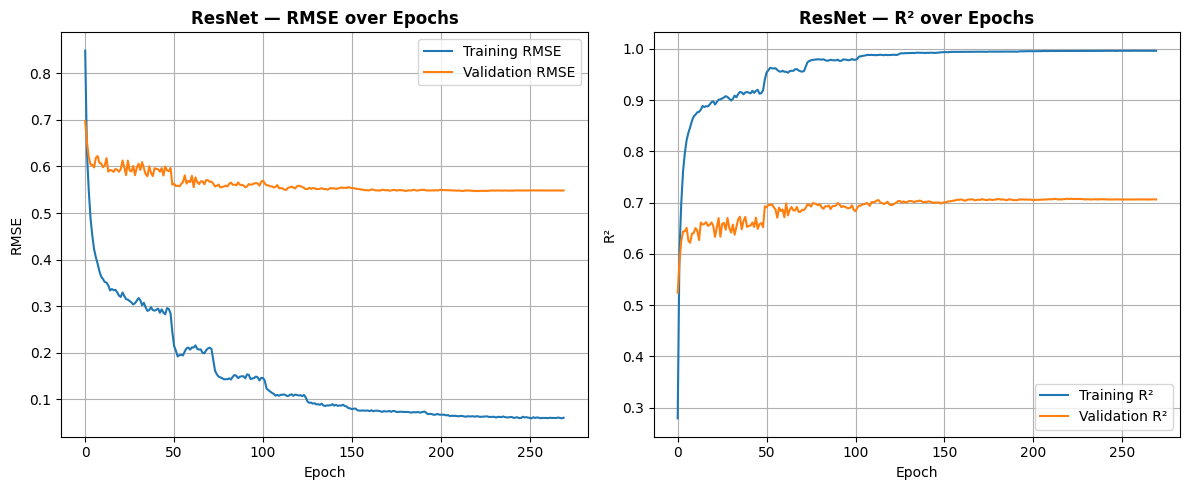

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history_res.history['RootMeanSquaredError'], label='Training RMSE')
axes[0].plot(history_res.history['val_RootMeanSquaredError'], label='Validation RMSE')
axes[0].set_title('ResNet — RMSE over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_res.history['r2_score'], label='Training R²')
axes[1].plot(history_res.history['val_r2_score'], label='Validation R²')
axes[1].set_title('ResNet — R² over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('R²')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Test Set Evaluation

In [ ]:

y_test_pred_res_scaled = model_res.predict(X_test_scaled, verbose=0)
y_test_pred_res = scaler_y.inverse_transform(y_test_pred_res_scaled).flatten()

res_test_rmse = np.sqrt(mean_squared_error(Y_test, y_test_pred_res))
res_test_mae  = mean_absolute_error(Y_test, y_test_pred_res)
res_test_r2   = r2_score(Y_test, y_test_pred_res)

print("Test Set Performance : ResNet (scaffold-based split):")
print(f"  RMSE : {res_test_rmse:.4f}")
print(f"  MAE  : {res_test_mae:.4f}")
print(f"  R²   : {res_test_r2:.4f}")

# Read Baseline NN and Dropout NN results from model_info.txt for accurate comparison
nn_results = {}
try:
    with open('model_info.txt', 'r') as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) == 3:
                name, rmse, r2 = parts[0].strip(), float(parts[1].strip()), float(parts[2].strip())
                if name not in nn_results:          
                    nn_results[name] = (rmse, r2)
except FileNotFoundError:
    pass

baseline_rmse, baseline_r2 = nn_results.get('Model_NN', (float('nan'), float('nan')))
dropout_rmse,  dropout_r2  = nn_results.get('Model_NN_Dropout', (float('nan'), float('nan')))

print("\n Comparison with baseline (from 5_Neural_Network.ipynb) ---")
print(f"  BaselineNN_RMSE: {baseline_rmse:.4f}, R²: {baseline_r2:.4f}")
print(f"  Dropout_NN_RMSE: {dropout_rmse:.4f},  R²: {dropout_r2:.4f}")
print(f"  ResNet_RMSE: {res_test_rmse:.4f}, R²: {res_test_r2:.4f}")


Test Set Performance — ResNet (scaffold-based split):
  RMSE : 0.9554
  MAE  : 0.6502
  R²   : 0.5659

--- Comparison with baseline (from 5_Neural_Network.ipynb) ---
  Baseline NN  — RMSE: ~0.xxxx, R²: ~0.70
  Dropout  NN  — RMSE: ~0.xxxx, R²: ~0.71
  ResNet       — RMSE: 0.9554, R²: 0.5659


#### Predicted vs Actual Plot

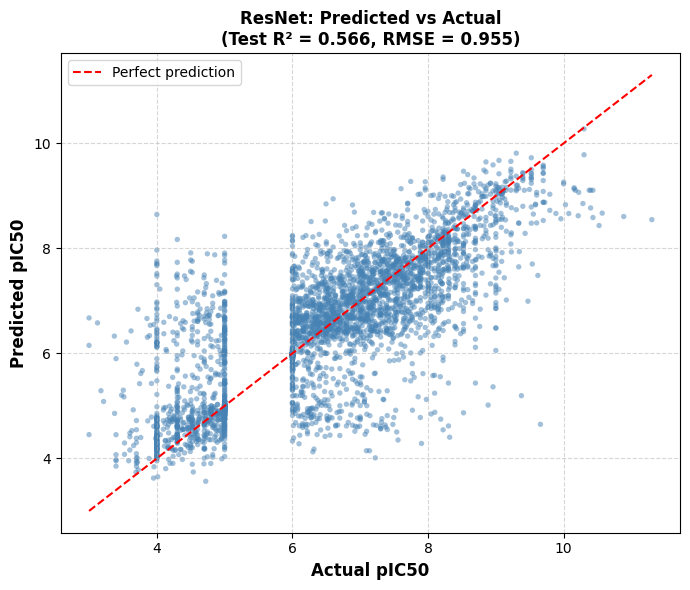

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(Y_test, y_test_pred_res, alpha=0.5, color='steelblue', edgecolors='none', s=15)
lims = [min(Y_test.min(), y_test_pred_res.min()),
        max(Y_test.max(), y_test_pred_res.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual pIC50', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize=12, fontweight='bold')
ax.set_title(f'ResNet: Predicted vs Actual\n'
             f'(Test R² = {res_test_r2:.3f}, RMSE = {res_test_rmse:.3f})',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

####  Save Results to model_info.txt

In [9]:
def save_model_info(model_name, test_rmse, r2):
    with open('model_info.txt', 'a') as f:
        f.write(f"{model_name},{test_rmse:.4f}, {r2:.4f}\n")

save_model_info('Model_ResNet', res_test_rmse, res_test_r2)
print("Results saved to model_info.txt")

Results saved to model_info.txt
